In [1]:
numero_scenario = 4

`S4` (Simplification clients à Jour) : Regroupement des statuts sans retard ($\text{PAY}_n \in \{-2, -1\} \implies 0$)  
L'objectif de ce nouvel apprentissage est de visualiser l'effet d'un regroupement des différents statuts de paiement à jour :  
- '-2', '-1', '0' sont regroupés en une codification uniquement '0'

In [2]:
import pandas as pd
from pathlib import Path

# 1. Dossier courant du notebook
current_dir = Path.cwd()

# 2. Retrouve automatiquement la racine du projet (là où se trouve le dossier 'data')
# Remonte l'arborescence jusqu'à trouver le dossier 'data'
root_dir = next(
    p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists()
)

# 3. Chemin vers le fichier
file_path = root_dir / "data" / "cleaned2_creditcard.csv"

# 4. Chargement du CSV
df = pd.read_csv(file_path)

In [3]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_AMT1_to_BILL_AMT2', 'ratio_PAY_AMT2_to_BILL_AMT3',
       'ratio_PAY_AMT3_to_BILL_AMT4', 'ratio_PAY_AMT4_to_BILL_AMT5',
       'ratio_PAY_AMT5_to_BILL_AMT6'],
      dtype='str')

In [4]:
# Modification des codifications des PAY_n

# Définir les colonnes PAY_AMT à traiter
pay_columns = [f'PAY_{i}' for i in range(1, 7)]  # PAY_1 à PAY_6
# Filtrer seulement les colonnes qui existent dans le DataFrame
pay_columns = [col for col in pay_columns if col in df.columns]

# Appliquer la codification de risque simplifiée
for col in pay_columns:
    # Remplacer les valeurs <0 par 0
    df[col] = df[col].apply(lambda x: 0 if x <0 else x)

print("Codification de risque simplifiée appliquée aux colonnes PAY_ :")
print("-2 devient 0")
print("-1 devient 0") 
print("0 reste 0")
print("Les valeurs positivent restent inchangées")

print("Vérification de la présence de valeurs < 0 dans les colonnes PAY_ :")

# Vérifier chaque colonne
for col in pay_columns:
    # Compter le nombre de valeurs > 2
    count_negative = (df[col] < 0).sum()
    # Afficher les statistiques
    print(f"{col}:")
    print(f"  Nombre de valeurs < 0 : {count_negative}")
    print(f"  Valeur maximale : {df[col].max()}")
    print(f"  Valeur minimale : {df[col].min()}")
    print(f"  Nombre total de valeurs : {len(df[col])}")
    print()

# Vérification globale
total_negative = sum((df[col] < 0).sum() for col in pay_columns if col in df.columns)
print(f"Total de valeurs < 0 dans toutes les colonnes PAY_n : {total_negative}")

# Si des valeurs > 2 existent, on peut appliquer la transformation
if total_negative > 0:
    print("\nDes valeurs inférieures à 0 ont été détectées.")
    print("Vous pouvez maintenant appliquer la codification simplifiée.")
else:
    print("\nAucune valeur inférieure à 0 n'a été détectée.")
    print("La modification a entièrement été effectuée.")

Codification de risque simplifiée appliquée aux colonnes PAY_ :
-2 devient 0
-1 devient 0
0 reste 0
Les valeurs positivent restent inchangées
Vérification de la présence de valeurs < 0 dans les colonnes PAY_ :
PAY_1:
  Nombre de valeurs < 0 : 0
  Valeur maximale : 8
  Valeur minimale : 0
  Nombre total de valeurs : 29136

PAY_2:
  Nombre de valeurs < 0 : 0
  Valeur maximale : 8
  Valeur minimale : 0
  Nombre total de valeurs : 29136

PAY_3:
  Nombre de valeurs < 0 : 0
  Valeur maximale : 8
  Valeur minimale : 0
  Nombre total de valeurs : 29136

PAY_4:
  Nombre de valeurs < 0 : 0
  Valeur maximale : 8
  Valeur minimale : 0
  Nombre total de valeurs : 29136

PAY_5:
  Nombre de valeurs < 0 : 0
  Valeur maximale : 8
  Valeur minimale : 0
  Nombre total de valeurs : 29136

PAY_6:
  Nombre de valeurs < 0 : 0
  Valeur maximale : 8
  Valeur minimale : 0
  Nombre total de valeurs : 29136

Total de valeurs < 0 dans toutes les colonnes PAY_n : 0

Aucune valeur inférieure à 0 n'a été détectée.
La

In [5]:
# Analyse de la distribution de la variable cible dp_nm
print("=== ANALYSE DE LA DISTRIBUTION DE dpnm ===")

# Compter les occurrences de chaque valeur
target_counts = df['dpnm'].value_counts()
print("\nNombre d'observations par classe :")
print(target_counts)

# Calculer les proportions
target_proportions = df['dpnm'].value_counts(normalize=True)
print("\nProportion de chaque classe :")
print(target_proportions)

# Afficher les pourcentages
print("\nPourcentage de chaque classe :")
for class_label, count in target_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Classe {class_label}: {count} observations ({percentage:.2f}%)")

# Vérification si le dataset est équilibré
print("\n=== ÉQUILIBRE DU DATASET ===")
imbalance_ratio = target_counts.min() / target_counts.max()
print(f"Ratio d'équilibre (min/max): {imbalance_ratio:.3f}")

print("\n=== RÉSUMÉ ===")
print(f"Total d'observations : {len(df)}")
print(f"Classes présentes : {sorted(target_counts.index.tolist())}")

=== ANALYSE DE LA DISTRIBUTION DE dpnm ===

Nombre d'observations par classe :
dpnm
0    22817
1     6319
Name: count, dtype: int64

Proportion de chaque classe :
dpnm
0    0.783121
1    0.216879
Name: proportion, dtype: float64

Pourcentage de chaque classe :
Classe 0: 22817 observations (78.31%)
Classe 1: 6319 observations (21.69%)

=== ÉQUILIBRE DU DATASET ===
Ratio d'équilibre (min/max): 0.277

=== RÉSUMÉ ===
Total d'observations : 29136
Classes présentes : [0, 1]


In [6]:
from sklearn.model_selection import train_test_split

# Séparation test / entrainement
y = df['dpnm']
X = df.drop('dpnm', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
# Séparation des colonnes numériques et catégorielles
num_col = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
cat_col = ['SEX', 'EDUCATION', 'MARRIAGE']
ord_col = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

Je commence par un apprentissage sur le F2 score

In [8]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# 0. Réinitialisation impérative des index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 1. Calcul dynamique du pourcentage de la classe 1
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion des catégories inconnues en validation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

# 2 bis. Scorer F2 (recall pondéré 4x plus que la precision, cf. fbeta_score beta=2)
f2_scorer = make_scorer(fbeta_score, beta=2)

# 3. Dictionnaire des modèles
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'SVM': make_pipeline(
        preprocessor,
        CalibratedClassifierCV(
            estimator=SVC(class_weight='balanced', random_state=42),
            ensemble=False,
        ),
    ),
    'MLPClassifier': make_pipeline(
        preprocessor,
        MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=500,
            random_state=42,
            early_stopping=True,
        ),
    ),
    'KNN': make_pipeline(
        preprocessor, KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print('Spot-check (F2-score) avec mesure du surapprentissage & extraction des poids...\n')

# 4. Boucle d'évaluation
for name, model in models.items():
    # A. Évaluation CV sur F2
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=f2_scorer,
        return_train_score=True,
        error_score='raise',  # Relève directement l'exception si un pli échoue
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'F2 Train': round(train_score, 4),
        'F2 Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check
df_results = pd.DataFrame(results).sort_values(
    by='F2 Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK (F2-SCORE) ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results.to_string(index=False))

# 6. Extraction dynamique des noms de features transformées
premier_pipeline = list(fitted_models.values())[0]
transformed_features = premier_pipeline[0].get_feature_names_out()
clean_features = [
    f.replace('num__', '').replace('nom__', '').replace('ord__', '')
    for f in transformed_features
]

df_importances = pd.DataFrame(importances_dict, index=clean_features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check (F2-score) avec mesure du surapprentissage & extraction des poids...



  -> SVM : pas de poids d'importance natifs.


  -> KNN : pas de poids d'importance natifs.



--- RÉSULTATS DU SPOT-CHECK (F2-SCORE) ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  F2 Train  F2 Val (Validation)  Écart (Overfit)  Std Val
          CatBoost    0.7477               0.5642           0.1835   0.0071
LogisticRegression    0.5394               0.5401          -0.0007   0.0082
               SVM    0.5505               0.5022           0.0483   0.0115
      RandomForest    0.9979               0.5019           0.4960   0.0052
     MLPClassifier    0.4360               0.4298           0.0063   0.0278
               KNN    0.4980               0.3736           0.1244   0.0102

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     19.33           4.95         10.23     10.29        11.20
EDUCATION_4               23.17           5.05          0.16      0.69         7.27
LIMIT_BAL                  5.83           3.49          5.77      7.84         5.73
BI

Je fais un apprentissage sur le ROC AUC cette fois

In [9]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# 0. Réinitialisation impérative des index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

# 1. Calcul dynamique du ratio pour déséquilibre de classes
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet sécurisé
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(
                drop='first', sparse_output=False, handle_unknown='ignore'
            ),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

# 3. Dictionnaire des modèles
models = {
    'LogisticRegression': make_pipeline(
        preprocessor,
        LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42
        ),
    ),
    'SVM': make_pipeline(
        preprocessor,
        CalibratedClassifierCV(
            estimator=SVC(class_weight='balanced', random_state=42),
            ensemble=False,
        ),
    ),
    'MLPClassifier': make_pipeline(
        preprocessor,
        MLPClassifier(
            hidden_layer_sizes=(50, 25),
            max_iter=500,
            random_state=42,
            early_stopping=True,
        ),
    ),
    'KNN': make_pipeline(
        preprocessor, KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ),
    'RandomForest': make_pipeline(
        preprocessor,
        RandomForestClassifier(
            class_weight='balanced', random_state=42, n_jobs=-1
        ),
    ),
    'CatBoost': make_pipeline(
        preprocessor,
        CatBoostClassifier(
            scale_pos_weight=scale_pos,
            random_state=42,
            verbose=0,
            thread_count=-1,
        ),
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
importances_dict = {}
fitted_models = {}

print('Spot-check ROC AUC & extraction des poids...\n')

# 4. Boucle d'évaluation sur ROC AUC
for name, model in models.items():
    # A. Évaluation CV (ROC AUC)
    cv_res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        return_train_score=True,
        error_score='raise',
        n_jobs=-1,
    )

    train_score = np.mean(cv_res['train_score'])
    test_score = np.mean(cv_res['test_score'])

    results.append({
        'Modèle': name,
        'ROC AUC Train': round(train_score, 4),
        'ROC AUC Val (Validation)': round(test_score, 4),
        'Écart (Overfit)': round(train_score - test_score, 4),
        'Std Val': round(np.std(cv_res['test_score']), 4),
    })

    # B. Fit final sur l'ensemble X_train
    model.fit(X_train, y_train)
    fitted_models[name] = model

    # C. Extraction des poids d'importance
    clf = model[-1]

    if isinstance(clf, CalibratedClassifierCV):
        clf_estimator = (
            clf.calibrated_classifiers_[0].estimator
            if hasattr(clf, 'calibrated_classifiers_')
            else clf.estimator
        )
    else:
        clf_estimator = clf

    if hasattr(clf_estimator, 'feature_importances_'):
        raw_imp = clf_estimator.feature_importances_
    elif hasattr(clf_estimator, 'coef_'):
        raw_imp = np.abs(clf_estimator.coef_[0])
    elif hasattr(clf_estimator, 'coefs_'):
        raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
    else:
        print(
            f"  -> {name} : pas de poids d'importance natifs."
        )
        continue

    total = raw_imp.sum()
    importances_dict[name] = (raw_imp / total) * 100 if total > 0 else raw_imp

# 5. Affichage des résultats du Spot-Check ROC AUC
df_results_auc = pd.DataFrame(results).sort_values(
    by='ROC AUC Val (Validation)', ascending=False
)
print("\n--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---")
print(df_results_auc.to_string(index=False))

# 6. Extraction dynamique des noms de features transformées
premier_pipeline = list(fitted_models.values())[0]
transformed_features = premier_pipeline[0].get_feature_names_out()
clean_features = [
    f.replace('num__', '').replace('nom__', '').replace('ord__', '')
    for f in transformed_features
]

df_importances = pd.DataFrame(importances_dict, index=clean_features)
if not df_importances.empty:
    df_importances['Moyenne (%)'] = df_importances.mean(axis=1)
    df_importances = df_importances.sort_values(
        by='Moyenne (%)', ascending=False
    ).round(2)

    print('\n--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---')
    print(df_importances.to_string())

Spot-check ROC AUC & extraction des poids...



  -> SVM : pas de poids d'importance natifs.


  -> KNN : pas de poids d'importance natifs.



--- RÉSULTATS DU SPOT-CHECK (ROC AUC) ET CONTRÔLE DE L'OVERFITTING ---
            Modèle  ROC AUC Train  ROC AUC Val (Validation)  Écart (Overfit)  Std Val
          CatBoost         0.9135                    0.7742           0.1394   0.0049
     MLPClassifier         0.7803                    0.7699           0.0104   0.0074
      RandomForest         1.0000                    0.7665           0.2335   0.0028
               SVM         0.8107                    0.7598           0.0509   0.0036
LogisticRegression         0.7630                    0.7597           0.0033   0.0064
               KNN         0.8804                    0.7022           0.1782   0.0023

--- IMPORTANCE DES FEATURES SELON CHAQUE MODÈLE (%) ---
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     19.33           4.95         10.23     10.29        11.20
EDUCATION_4               23.17           5.05          0.16      0.69         7.27
LIMIT_BAL        

KNN reste en retrait sur les 2 évaluations  
RandomForest apprend par coeur, il doit etre bridé au niveau de la profondeur  
Catboost est le modèle le plus performant dans les 2 cas mais souffre d'un peu de surapprentissage  
MLPClassifier s'en sort très bien au niveau du ROC AUC  
Logisticregression et SVM sont stables  

On tente d'améliorer les hyperparamètres sur les modèles restants en se basant sur les 2 types de score : le ROC AUC et le F2 score

In [10]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

# 1. Calcul dynamique du déséquilibre de classe
percentage = (y_train == 1).mean() * 100
scale_pos = (100 - percentage) / percentage

# 2. Transformateur complet avec gestion d'erreurs sur catégories inconnues
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        (
            'nom',
            OneHotEncoder(sparse_output=False, handle_unknown='ignore'),
            cat_col,
        ),
        (
            'ord',
            OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ),
            ord_col,
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2 bis. Scorer F2 (recall pondéré 4x plus que la precision)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Correspondance nom de métrique -> scorer utilisable par GridSearchCV
scoring_map = {'roc_auc': 'roc_auc', 'f2': f2_scorer}

# 3. Modèles et grilles d'hyperparamètres
experiments = {
    'LogisticRegression': {
        'pipeline': make_pipeline(
            preprocessor,
            LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
        ),
        'params': {
            'logisticregression__C': [0.01, 0.1, 1.0, 10.0],
        },
    },
    'SVM': {
        'pipeline': make_pipeline(
            preprocessor,
            CalibratedClassifierCV(
                estimator=SVC(class_weight='balanced', random_state=42),
                ensemble=False,
            ),
        ),
        'params': {
            'calibratedclassifiercv__estimator__C': [0.5, 1, 2],
            'calibratedclassifiercv__estimator__gamma': ['scale', 'auto'],
        },
    },
    'MLPClassifier': {
        'pipeline': make_pipeline(
            preprocessor,
            MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
        ),
        'params': {
            'mlpclassifier__hidden_layer_sizes': [(32, 16), (64, 32), (32,)],
            'mlpclassifier__alpha': [0.01, 0.1, 1.0],
        },
    },
    'KNN': {
        'pipeline': make_pipeline(
            preprocessor,
            KNeighborsClassifier(n_jobs=-1),
        ),
        'params': {
            'kneighborsclassifier__n_neighbors': [3, 5, 7, 11, 15],
            'kneighborsclassifier__weights': ['uniform', 'distance'],
        },
    },
    'RandomForest': {
        'pipeline': make_pipeline(
            preprocessor,
            RandomForestClassifier(
                class_weight='balanced', random_state=42, n_jobs=-1
            ),
        ),
        'params': {
            'randomforestclassifier__max_depth': [6, 8, 10],
            'randomforestclassifier__min_samples_leaf': [20, 50, 100],
            'randomforestclassifier__n_estimators': [200, 300],
        },
    },
    'CatBoost': {
        'pipeline': make_pipeline(
            preprocessor,
            CatBoostClassifier(
                scale_pos_weight=scale_pos,
                random_state=42,
                verbose=0,
                thread_count=-1,
            ),
        ),
        'params': {
            'catboostclassifier__depth': [4, 6],
            'catboostclassifier__l2_leaf_reg': [5, 10, 15],
            'catboostclassifier__learning_rate': [0.03, 0.05],
        },
    },
}

# Structure de stockage des résultats
best_models = {'roc_auc': {}, 'f2': {}}
grid_results = {'roc_auc': [], 'f2': []}

# 4. Exécution de l'optimisation
for metric in ['roc_auc', 'f2']:
    print(f'Optimisation avec le scoring : {metric.upper()}...\n')

    for name, exp in experiments.items():
        grid = GridSearchCV(
            estimator=exp['pipeline'],
            param_grid=exp['params'],
            cv=cv,
            scoring=scoring_map[metric],
            return_train_score=True,
            n_jobs=-1,
        )
        grid.fit(X_train, y_train)

        best_models[metric][name] = grid.best_estimator_

        best_idx = grid.best_index_
        train_score = grid.cv_results_['mean_train_score'][best_idx]
        val_score = grid.cv_results_['mean_test_score'][best_idx]
        val_std = grid.cv_results_['std_test_score'][best_idx]

        grid_results[metric].append({
            'Modèle': name,
            'Score Train': round(train_score, 4),
            'Score Val': round(val_score, 4),
            'Écart (Overfit)': round(train_score - val_score, 4),
            'Std Val': round(val_std, 4),
            'Meilleurs Paramètres': grid.best_params_,
        })

# 5. Sauvegarde des tableaux de résultats par métrique (utilisés en aval : matrices
#    de confusion en validation et comparatif final Train/Val/Test) + affichage des synthèses
grid_results_df = {}

for metric in ['roc_auc', 'f2']:
    df_res = pd.DataFrame(grid_results[metric]).sort_values(
        by='Score Val', ascending=False
    )
    grid_results_df[metric] = df_res

    print(f"\n================ RÉSULTATS OPTIMISÉS ({metric.upper()}) ================")
    print(
        df_res[
            ['Modèle', 'Score Train', 'Score Val', 'Écart (Overfit)', 'Std Val']
        ].to_string(index=False)
    )

    print(f"\n--- MEILLEURS HYPERPARAMÈTRES ({metric.upper()}) ---")
    for row in grid_results[metric]:
        print(f"\n[{row['Modèle']}]")
        for param, val in row['Meilleurs Paramètres'].items():
            clean_param = param.split('__')[-1]
            print(f'  - {clean_param}: {val}')

# Tableaux "post-tuning" exposés pour la suite du notebook (cellules confusion matrix / comparatif final)
df_grid_f2 = grid_results_df['f2'].set_index('Modèle')
df_grid_auc = grid_results_df['roc_auc'].set_index('Modèle')

Optimisation avec le scoring : ROC_AUC...



Optimisation avec le scoring : F2...




================ RÉSULTATS OPTIMISÉS (ROC_AUC) ================
            Modèle  Score Train  Score Val  Écart (Overfit)  Std Val
      RandomForest       0.8417     0.7801           0.0616   0.0040
          CatBoost       0.8424     0.7785           0.0639   0.0048
     MLPClassifier       0.7867     0.7746           0.0121   0.0062
               SVM       0.7968     0.7657           0.0311   0.0034
LogisticRegression       0.7629     0.7603           0.0027   0.0062
               KNN       0.8233     0.7385           0.0848   0.0065

--- MEILLEURS HYPERPARAMÈTRES (ROC_AUC) ---

[LogisticRegression]
  - C: 0.01

[SVM]
  - C: 0.5
  - gamma: auto

[MLPClassifier]
  - alpha: 0.1
  - hidden_layer_sizes: (32, 16)

[KNN]
  - n_neighbors: 15
  - weights: uniform

[RandomForest]
  - max_depth: 10
  - min_samples_leaf: 20
  - n_estimators: 300

[CatBoost]
  - depth: 4
  - l2_leaf_reg: 10
  - learning_rate: 0.03

================ RÉSULTATS OPTIMISÉS (F2) ================
            Modè

Je regarde maintenant les matrices de confusion sur les meilleurs modèles


=== IMPORTANCE DES FEATURES (Optimisé ROC AUC) ===
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     23.71           3.71         28.40     27.34        20.79
LIMIT_BAL                  7.57           3.37          5.36      8.39         6.17
PAY_3                      7.16           3.14          7.75      3.06         5.28
PAY_2                      0.22           3.51         13.62      1.88         4.81
PAY_4                      5.01           3.44          5.84      2.35         4.16
PAY_AMT1                   3.68           3.29          3.51      5.32         3.95
BILL_AMT1                  2.15           3.51          2.88      7.02         3.89
PAY_6                      7.40           3.28          3.05      1.68         3.85
PAY_AMT2                   3.13           3.73          3.38      4.64         3.72
BILL_AMT3                  3.62           3.40          2.03      3.53         3.15
EDUCATION_4             

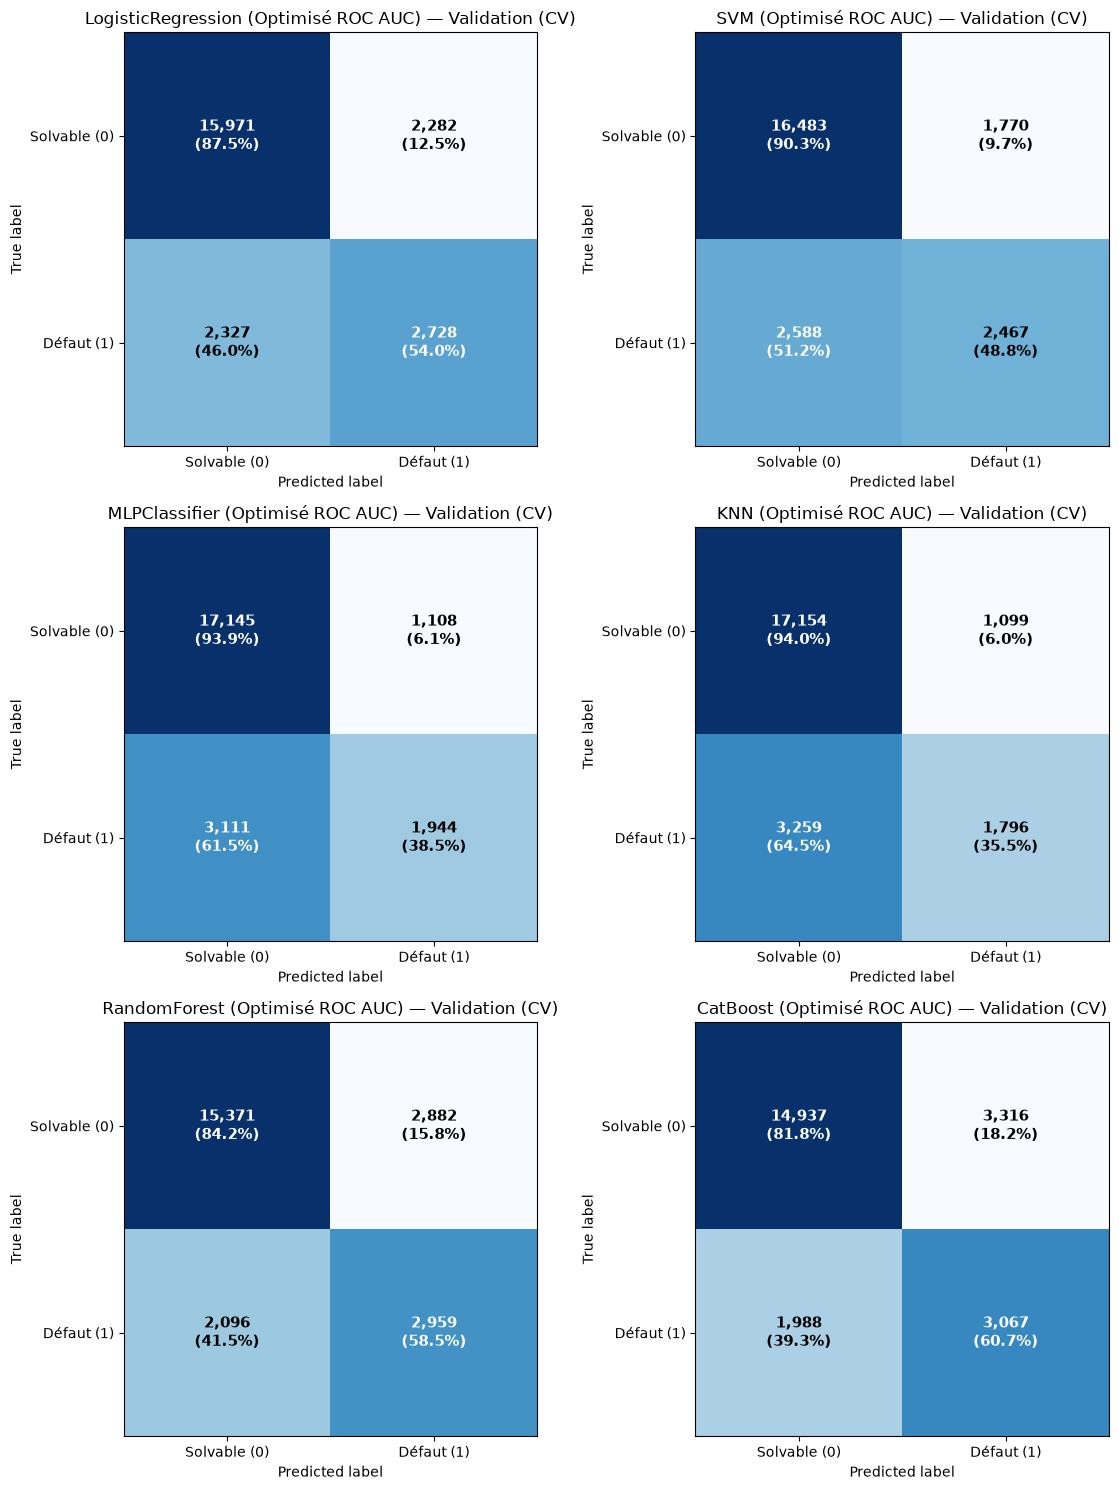


=== IMPORTANCE DES FEATURES (Optimisé F2-Score) ===
             LogisticRegression  MLPClassifier  RandomForest  CatBoost  Moyenne (%)
PAY_1                     23.71           4.01         31.11     26.60        21.36
LIMIT_BAL                  7.57           3.55          5.73      8.22         6.27
PAY_3                      7.16           3.28          9.18      3.16         5.69
PAY_2                      0.22           3.78         15.51      1.80         5.33
PAY_4                      5.01           3.93          6.67      2.10         4.43
PAY_6                      7.40           3.45          3.27      1.74         3.97
PAY_AMT1                   3.68           3.59          3.16      5.01         3.86
BILL_AMT1                  2.15           3.49          2.19      7.54         3.84
EDUCATION_4                8.76           4.01          0.01      1.13         3.48
PAY_AMT2                   3.13           3.07          2.95      4.59         3.44
PAY_5                  

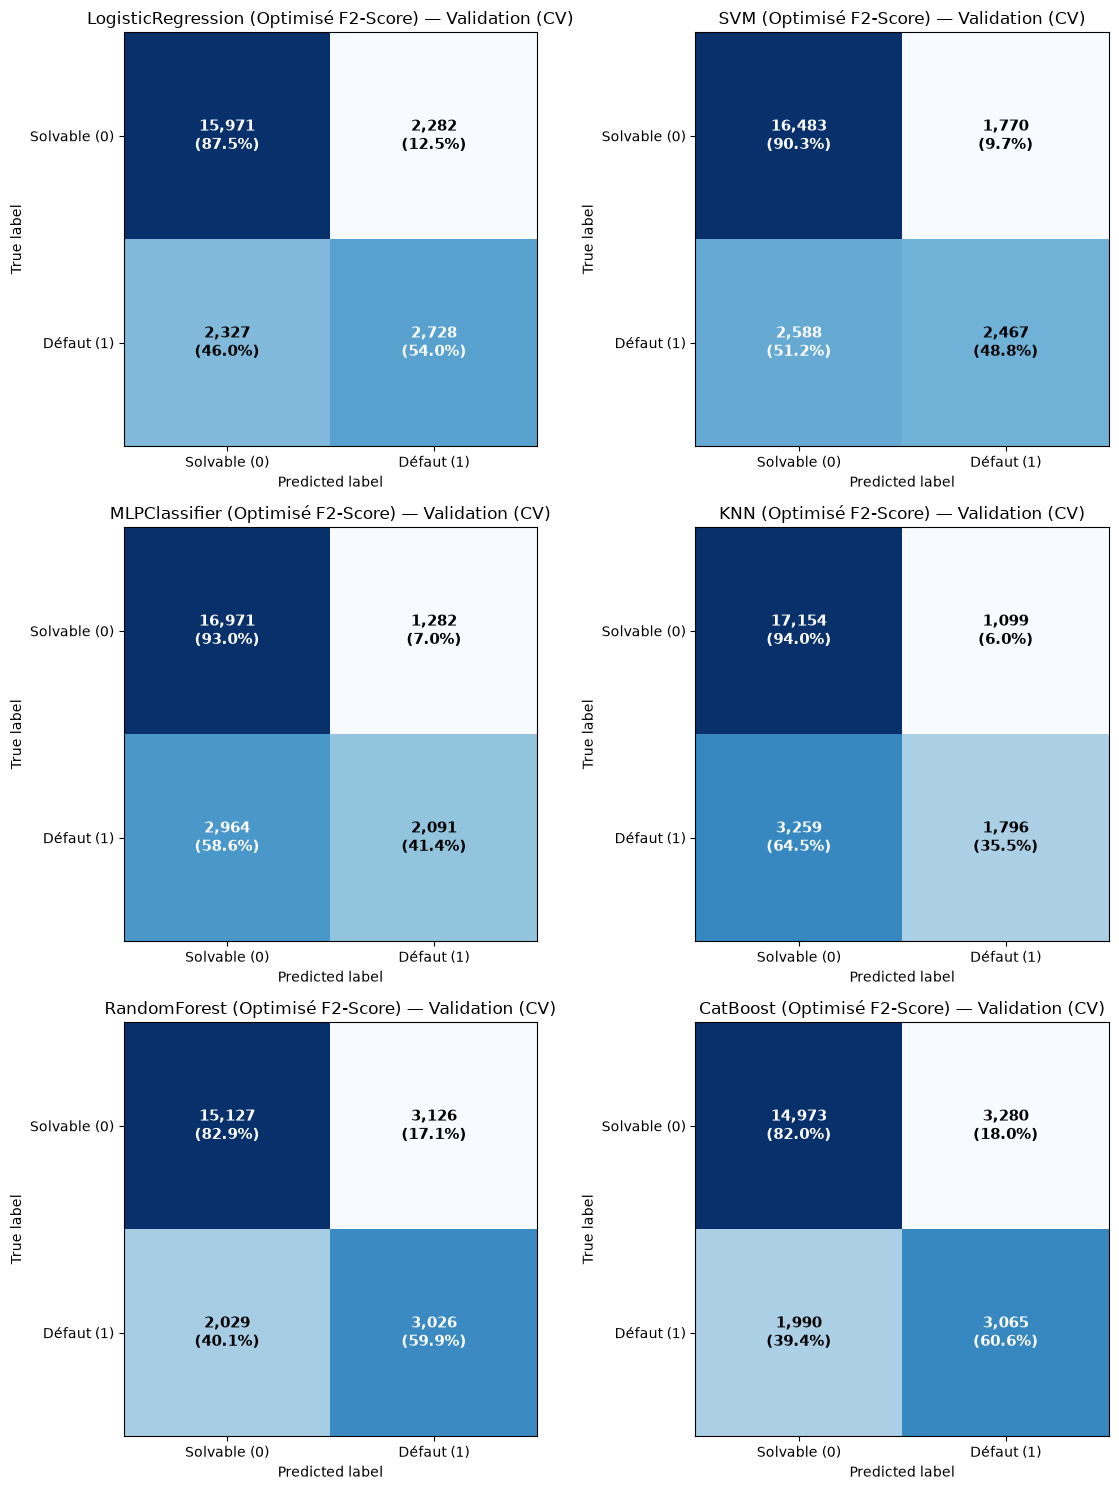

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict


def analyser_modeles(dict_modeles, titre_metric):
    # A. Importances de variables
    importances_dict = {}

    # 1. Extraction dynamique des vrais noms de features après transformation
    premier_pipeline = list(dict_modeles.values())[0]
    transformed_features = premier_pipeline[0].get_feature_names_out()
    clean_features = [
        f.replace("num__", "").replace("nom__", "").replace("ord__", "")
        for f in transformed_features
    ]

    for name, model in dict_modeles.items():
        clf = model[-1]

        if isinstance(clf, CalibratedClassifierCV):
            clf_estimator = (
                clf.calibrated_classifiers_[0].estimator
                if hasattr(clf, "calibrated_classifiers_")
                else clf.estimator
            )
        else:
            clf_estimator = clf

        if hasattr(clf_estimator, "feature_importances_"):
            raw_imp = clf_estimator.feature_importances_
        elif hasattr(clf_estimator, "coef_"):
            raw_imp = np.abs(clf_estimator.coef_[0])
        elif hasattr(clf_estimator, "coefs_"):
            raw_imp = np.abs(clf_estimator.coefs_[0]).sum(axis=1)
        else:
            continue

        total = raw_imp.sum()
        importances_dict[name] = (
            (raw_imp / total) * 100 if total > 0 else raw_imp
        )

    # 2. DataFrame construit avec le bon index (clean_features)
    df_imp = pd.DataFrame(importances_dict, index=clean_features)
    if not df_imp.empty:
        df_imp["Moyenne (%)"] = df_imp.mean(axis=1)
        df_imp = df_imp.sort_values(by="Moyenne (%)", ascending=False).round(2)

        print(f"\n=== IMPORTANCE DES FEATURES ({titre_metric}) ===")
        print(df_imp.to_string())

    # B. Matrices de confusion EN VALIDATION CROISÉE + Stockage des Rappels Validation
    #
    # Les modèles reçus (dict_modeles) sont déjà entraînés sur X_train en entier
    # (grid.best_estimator_), mais cross_validate/GridSearchCV ne conservent pas
    # les prédictions out-of-fold, seulement les scores agrégés. Pour afficher une
    # matrice de confusion représentative de la VALIDATION (et non un simple
    # rappel des données d'entraînement), on utilise cross_val_predict avec les
    # hyperparamètres déjà optimisés : chaque pli est prédit par un modèle qui ne
    # l'a jamais vu pendant son fit. Aucun nouvel entraînement final n'est refait
    # (pas de nouvelle recherche d'hyperparamètres) ; seul le refit par pli,
    # inhérent à toute validation croisée, a lieu ici.
    cv_cm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    n_models = len(dict_modeles)
    n_cols = 2 if n_models > 1 else 1
    n_rows = (n_models + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten() if n_models > 1 else [axes]

    recalls_val = {}

    for idx, (name, model) in enumerate(dict_modeles.items()):
        # Prédictions out-of-fold (validation croisée), pas sur X_train directement
        y_pred = cross_val_predict(
            model, X_train, y_train, cv=cv_cm, n_jobs=-1
        )
        cm = confusion_matrix(y_train, y_pred)

        # Taux de correspondance par classe réelle (ligne)
        cm_rate = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        # Récupération directe du Recall Validation (Ligne 1, Colonne 1)
        recalls_val[name] = cm_rate[1, 1]

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm_rate,
            display_labels=["Solvable (0)", "Défaut (1)"],
        )
        disp.plot(
            cmap="Blues",
            ax=axes[idx],
            colorbar=False,
            include_values=False,
        )

        # Injection des valeurs : Effectif + %
        for i in range(2):
            for j in range(2):
                count = cm[i, j]
                rate = cm_rate[i, j]
                text_label = f"{count:,}\n({rate:.1%})"

                color = "white" if rate > 0.5 else "black"
                axes[idx].text(
                    j,
                    i,
                    text_label,
                    ha="center",
                    va="center",
                    color=color,
                    fontweight="bold",
                    fontsize=11,
                )

        axes[idx].set_title(f"{name} ({titre_metric}) — Validation (CV)")

    for idx in range(n_models, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    return recalls_val


# Exécution et récupération des rappels (calculés en validation croisée)
recalls_val_auc = analyser_modeles(best_models['roc_auc'], "Optimisé ROC AUC")
recalls_val_f2 = analyser_modeles(best_models['f2'], "Optimisé F2-Score")


MLPClassifier semble doué pour détecter les vrais clients solvables, ce qui n'est pas le but recherché ici, il ne peut pas compenser via un hyperparamètre le déséquilibre de classe, on pourrait lui diminuer le seuil de décision ou faire un entrainement particulier compute_sample_weight pour compenser le déséquilibre

## Test final sur X_test

In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import fbeta_score, recall_score, roc_auc_score

print("=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS VALIDATION CV POST-TUNING) ===\n")


def generer_tableaux_analyse(
    dict_best_models, df_cv_results, dict_recalls_val, metric_name
):
    # df_cv_results est indexé par 'Modèle' et contient la colonne 'Score Val'
    # = score de VALIDATION croisée du meilleur jeu d'hyperparamètres (post-tuning,
    # cellule GridSearchCV), et non un score d'entraînement.
    cv_map = df_cv_results
    score_col = "Score Val"

    target_rows = []
    recall_rows = []

    for model_name, model in dict_best_models.items():
        # 1. Prédictions sur X_test
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        # 2. Métriques sur Test
        test_target = (
            roc_auc_score(y_test, y_pred_proba)
            if metric_name == "ROC AUC"
            else fbeta_score(y_test, y_pred, beta=2)
        )
        test_recall = recall_score(y_test, y_pred)

        # 3. Récupération du score de Validation CV (post-tuning) et du Recall Validation
        cv_target = cv_map.loc[model_name, score_col]
        val_recall = dict_recalls_val.get(model_name, np.nan)

        # 4. Calcul des écarts (Test vs Validation CV, plus Train vs Validation)
        diff_target = test_target - cv_target
        diff_recall = (
            (test_recall - val_recall) if pd.notna(val_recall) else np.nan
        )

        # Diagnostics
        diag_target = (
            "⚠️ Overfit important !" if diff_target < -0.10 else
            "⚠️ Overfit" if diff_target < -0.05 else
            "léger Overfit" if diff_target < -0.02 else
            "📈 Sous-estimé" if diff_target > 0.02 else
            "✅ Stable"
        )
        diag_recall = (
            "⚠️ baisse Rappel"
            if pd.notna(diff_recall) and diff_recall < -0.02
            else "✅ Stable"
        )

        # Tableau 1 : Métrique Cible (Validation CV vs Test)
        target_rows.append({
            "Modèle": model_name,
            f"{metric_name} (Val CV)": round(cv_target, 4),
            f"{metric_name} (Test)": round(test_target, 4),
            "Diff Target": round(diff_target, 4),
            "Diagnostic": diag_target,
        })

        # Tableau 2 : Métrique Rappel (Validation CV vs Test)
        recall_rows.append({
            "Modèle": model_name,
            "Recall (Val CV)": (
                round(val_recall, 4) if pd.notna(val_recall) else "N/A"
            ),
            "Recall (Test)": round(test_recall, 4),
            "Diff Recall": (
                round(diff_recall, 4) if pd.notna(diff_recall) else "N/A"
            ),
            "Diagnostic": diag_recall,
        })

    return pd.DataFrame(target_rows), pd.DataFrame(recall_rows)


# ---------------------------------------------------------
# A. BLOC OPTIMISÉ POUR F2-SCORE
# ---------------------------------------------------------
df_f2_target, df_f2_recall = generer_tableaux_analyse(
    best_models['f2'], df_grid_f2, recalls_val_f2, "F2 Score"
)

print("=" * 65)
print("🎯 1. OPTIMISATION : F2-SCORE")
print("=" * 65)

print("\n--- Tableau 1A : Stabilité Métrique Cible (F2-Score, Val CV vs Test) ---")
print(df_f2_target.to_string(index=False))

print("\n--- Tableau 1B : Dérive du Rappel (Recall Val CV vs Test) ---")
print(df_f2_recall.to_string(index=False))

print("\n\n")

# ---------------------------------------------------------
# B. BLOC OPTIMISÉ POUR ROC AUC
# ---------------------------------------------------------
df_auc_target, df_auc_recall = generer_tableaux_analyse(
    best_models['roc_auc'], df_grid_auc, recalls_val_auc, "ROC AUC"
)

print("=" * 65)
print("🎯 2. OPTIMISATION : ROC AUC")
print("=" * 65)

print("\n--- Tableau 2A : Stabilité Métrique Cible (ROC AUC, Val CV vs Test) ---")
print(df_auc_target.to_string(index=False))

print("\n--- Tableau 2B : Dérive du Rappel (Recall Val CV vs Test) ---")
print(df_auc_recall.to_string(index=False))

=== ÉVALUATION FINALE MULTI-TABLEAUX (X_TEST VS VALIDATION CV POST-TUNING) ===



🎯 1. OPTIMISATION : F2-SCORE

--- Tableau 1A : Stabilité Métrique Cible (F2-Score, Val CV vs Test) ---
            Modèle  F2 Score (Val CV)  F2 Score (Test)  Diff Target    Diagnostic
LogisticRegression             0.5406           0.5396      -0.0010      ✅ Stable
               SVM             0.5043           0.4993      -0.0050      ✅ Stable
     MLPClassifier             0.4429           0.4210      -0.0219 léger Overfit
               KNN             0.3885           0.3883      -0.0002      ✅ Stable
      RandomForest             0.5737           0.5768       0.0031      ✅ Stable
          CatBoost             0.5769           0.5797       0.0028      ✅ Stable

--- Tableau 1B : Dérive du Rappel (Recall Val CV vs Test) ---
            Modèle  Recall (Val CV)  Recall (Test)  Diff Recall       Diagnostic
LogisticRegression           0.5397         0.5380      -0.0017         ✅ Stable
               SVM           0.4880         0.4842      -0.0039         ✅ Stable
     MLPClassifie

🎯 2. OPTIMISATION : ROC AUC

--- Tableau 2A : Stabilité Métrique Cible (ROC AUC, Val CV vs Test) ---
            Modèle  ROC AUC (Val CV)  ROC AUC (Test)  Diff Target Diagnostic
LogisticRegression            0.7603          0.7558      -0.0045   ✅ Stable
               SVM            0.7657          0.7653      -0.0004   ✅ Stable
     MLPClassifier            0.7746          0.7649      -0.0097   ✅ Stable
               KNN            0.7385          0.7420       0.0035   ✅ Stable
      RandomForest            0.7801          0.7807       0.0006   ✅ Stable
          CatBoost            0.7785          0.7804       0.0019   ✅ Stable

--- Tableau 2B : Dérive du Rappel (Recall Val CV vs Test) ---
            Modèle  Recall (Val CV)  Recall (Test)  Diff Recall Diagnostic
LogisticRegression           0.5397         0.5380      -0.0017   ✅ Stable
               SVM           0.4880         0.4842      -0.0039   ✅ Stable
     MLPClassifier           0.3846         0.3940       0.0094   ✅ Stab

Pas de surapprentissage  
Attention : le recall sur MLPClassifier est dégradé, le réseau de neurones est à traiter peut etre à part car il n'intègre pas la faible proprotion de défaut de paiement dans la cible
Le meilleur modèle reste pour le moment CatBoost

Classification des modèles  
Choix du meilleur modèle selon : Moyenne de (F2 Score & AUC ROC)
Enregistrement du meilleur modèle

=== SCORE MAÎTRE, PODIUM ET SAUVEGARDE DU MEILLEUR MODÈLE ===



--- PODIUM COMPLET (6 candidats, triés par Score Maître) ---
          Candidat  F2 (Val CV)  ROC AUC (Val CV)  Recall (Val CV)  Score Maître
          CatBoost       0.5769            0.7779           0.6063        0.6774
      RandomForest       0.5737            0.7790           0.5986        0.6763
LogisticRegression       0.5406            0.7603           0.5397        0.6504
               SVM       0.5043            0.7657           0.4880        0.6350
     MLPClassifier       0.4429            0.7723           0.4136        0.6076
               KNN       0.3885            0.7385           0.3553        0.5635

🏆 PODIUM — TOP 3
🥇 CatBoost — Score Maître : 0.6774
🥈 RandomForest — Score Maître : 0.6763
🥉 LogisticRegression — Score Maître : 0.6504

>>> Meilleur modèle retenu : CatBoost

--- RÉCAPITULATIF DES MÉTRIQUES : CatBoost ---
Métrique  Val CV   Test  Écart (Test - Val CV)
      F2  0.5769 0.5797                 0.0028
 ROC AUC  0.7779 0.7799                 0.0020
  Recal

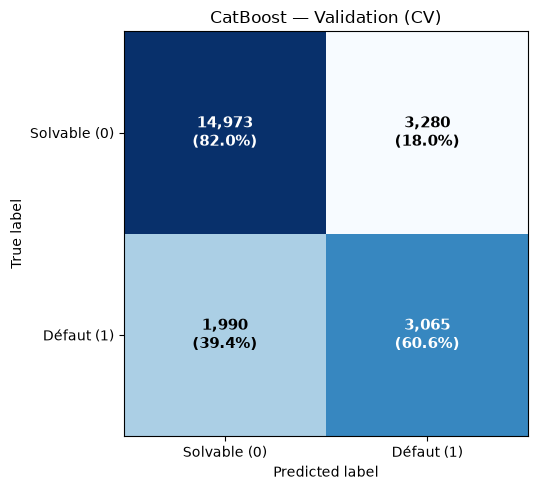


✅ Modèle sauvegardé : C:\Users\johan\VS Code Wild 2\PROJET_DEFAULT_CREDIT_CARD_ML\lab_ML\corrections_niveau2\best_models\model_S4_corrections_niveau2.joblib


In [13]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate

print("=== SCORE MAÎTRE, PODIUM ET SAUVEGARDE DU MEILLEUR MODÈLE ===\n")

# 1. Scorer F2 et grille de CV (mêmes paramètres que tout le notebook)
f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Regroupement des 6 candidats (1 pipeline par famille de modèle)
candidates = best_models['f2']

# 3. Ré-évaluation homogène des 6 candidats sur F2 + ROC AUC
#    (mêmes 5 plis pour tout le monde, aucun refit d'hyperparamètres)
podium_rows = []
for label, pipeline in candidates.items():
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={'f2': f2_scorer, 'roc_auc': 'roc_auc', 'recall': 'recall'},
        n_jobs=-1,
    )
    f2_val = np.mean(cv_scores['test_f2'])
    auc_val = np.mean(cv_scores['test_roc_auc'])
    recall_val = np.mean(cv_scores['test_recall'])

    podium_rows.append({
        "Candidat": label,
        "F2 (Val CV)": round(f2_val, 4),
        "ROC AUC (Val CV)": round(auc_val, 4),
        "Recall (Val CV)": round(recall_val, 4),
        "Score Maître": round((f2_val + auc_val) / 2, 4),
    })

# Tri par Score Maître (Remplacer by="Recall (Val CV)" si vous préférez privilégier le Recall pur)
df_podium = pd.DataFrame(podium_rows).sort_values(
    by="Score Maître", ascending=False
).reset_index(drop=True)

print("--- PODIUM COMPLET (6 candidats, triés par Score Maître) ---")
print(df_podium.to_string(index=False))

# 4. Top 3
print("\n" + "=" * 65)
print("🏆 PODIUM — TOP 3")
print("=" * 65)
for rank, row in df_podium.head(3).iterrows():
    medaille = ["🥇", "🥈", "🥉"][rank]
    print(f"{medaille} {row['Candidat']} — Score Maître : {row['Score Maître']}")

# 5. Sélection du meilleur candidat et récupération du pipeline + métadonnées
best_label = df_podium.iloc[0]["Candidat"]
best_pipeline = candidates[best_label]
best_model_name = best_label
best_direction = "f2"

print(f"\n>>> Meilleur modèle retenu : {best_label}")

# 6. Récap complet des métriques du meilleur modèle : Val CV vs Test
y_pred_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = best_pipeline.predict(X_test)

recap_best = pd.DataFrame([
    {
        "Métrique": "F2",
        "Val CV": df_podium.iloc[0]["F2 (Val CV)"],
        "Test": round(fbeta_score(y_test, y_pred_test, beta=2), 4),
    },
    {
        "Métrique": "ROC AUC",
        "Val CV": df_podium.iloc[0]["ROC AUC (Val CV)"],
        "Test": round(roc_auc_score(y_test, y_pred_proba_test), 4),
    },
    {
        "Métrique": "Recall",
        "Val CV": df_podium.iloc[0]["Recall (Val CV)"],
        "Test": round(recall_score(y_test, y_pred_test), 4),
    }
])
recap_best["Écart (Test - Val CV)"] = (
    recap_best["Test"] - recap_best["Val CV"]
).round(4)

print(f"\n--- RÉCAPITULATIF DES MÉTRIQUES : {best_label} ---")
print(recap_best.to_string(index=False))

# 7. Matrice de confusion du meilleur modèle, en validation croisée
#    (out-of-fold, même logique que la cellule d'analyse des modèles)
y_pred_cv_best = cross_val_predict(best_pipeline, X_train, y_train, cv=cv, n_jobs=-1)
cm_best = confusion_matrix(y_train, y_pred_cv_best)
cm_best_rate = cm_best.astype("float") / cm_best.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best_rate, display_labels=["Solvable (0)", "Défaut (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False, include_values=False)

for i in range(2):
    for j in range(2):
        count = cm_best[i, j]
        rate = cm_best_rate[i, j]
        color = "white" if rate > 0.5 else "black"
        ax.text(
            j, i, f"{count:,}\n({rate:.1%})",
            ha="center", va="center", color=color, fontweight="bold", fontsize=11,
        )

ax.set_title(f"{best_label} — Validation (CV)")
plt.tight_layout()
plt.show()

# 8. Sauvegarde du meilleur modèle en joblib
niveau_correction = Path.cwd().name  # nom du dossier courant du notebook

output_dir = Path.cwd() / "best_models"
output_dir.mkdir(exist_ok=True)

filename = f"model_S{numero_scenario}_{niveau_correction}.joblib"
output_path = output_dir / filename

joblib.dump(best_pipeline, output_path)
print(f"\n✅ Modèle sauvegardé : {output_path}")